In [1]:
import pytesseract
from PIL import Image
import pandas as pd
import os
import requests

print("✓ pytesseract:", pytesseract.get_tesseract_version())
print("✓ Arabic available:", "ara" in pytesseract.get_languages())
print("✓ Project folders:", os.listdir(".."))

✓ pytesseract: 5.5.2
✓ Arabic available: True
✓ Project folders: ['data', 'notebooks', 'src']


/Users/juhi/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [6]:
import os
from PIL import Image
import matplotlib.pyplot as plt

image_dir = "../data/raw_images/"
images = os.listdir(image_dir)
print(f"Found {len(images)} images:")
for img in images:
    size = os.path.getsize(image_dir + img)
    print(f"  - {img} ({size:,} bytes)")

Matplotlib is building the font cache; this may take a moment.


Found 5 images:
  - arabic_doc_005.jpg (198,082 bytes)
  - arabic_doc_004.jpg (370,157 bytes)
  - arabic_doc_003.jpg (295,600 bytes)
  - arabic_doc_002.jpg (2,464,982 bytes)
  - arabic_doc_001.jpg (341,477 bytes)


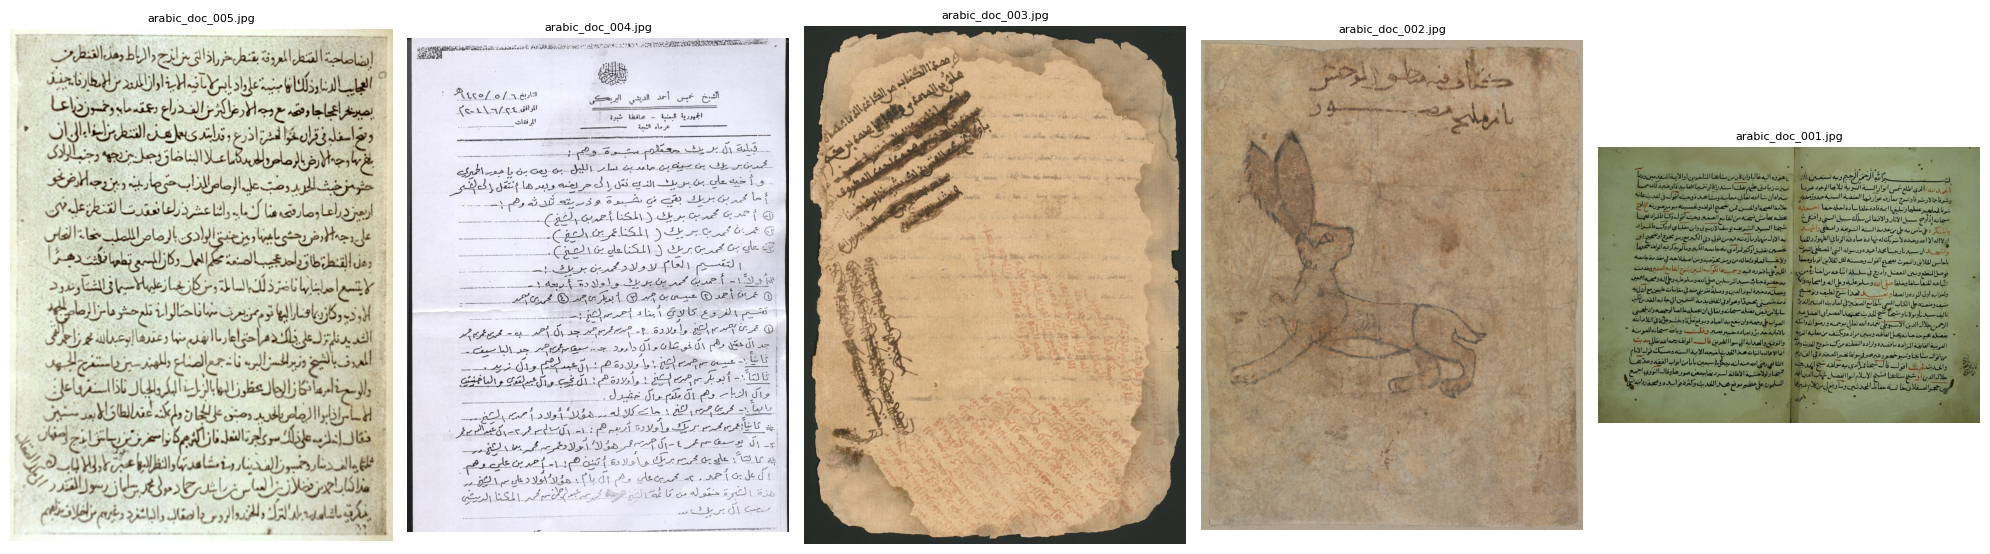

All images displayed!


In [7]:
fig, axes = plt.subplots(1, len(images), figsize=(20, 8))

if len(images) == 1:
    axes = [axes]

for i, img_name in enumerate(images):
    img = Image.open(image_dir + img_name)
    axes[i].imshow(img)
    axes[i].set_title(img_name[:20], fontsize=8)
    axes[i].axis('off')

plt.tight_layout()
plt.show()
print("All images displayed!")

In [9]:
import pytesseract
from PIL import Image
import os
import json

image_dir = "../data/raw_images/"
images = sorted(os.listdir(image_dir))

# Store results
ocr_results = {}

for img_name in images:
    img_path = image_dir + img_name
    img = Image.open(img_path)
    
    print(f"\n{'='*50}")
    print(f"Processing: {img_name}")
    print(f"Image size: {img.size}")
    
    # Run Arabic OCR
    text = pytesseract.image_to_string(img, lang='ara')
    
    ocr_results[img_name] = {
        "text": text,
        "char_count": len(text),
        "image_size": img.size
    }
    
    print(f"Characters extracted: {len(text)}")
    print(f"Preview: {text[:100]}...")

# Save results
os.makedirs("../data/ocr_output", exist_ok=True)
with open("../data/ocr_output/raw_ocr_results.json", "w", 
          encoding="utf-8") as f:
    json.dump(ocr_results, f, ensure_ascii=False, indent=2)

print("\n✓ All OCR results saved!")
print("\nSummary:")
for name, result in ocr_results.items():
    print(f"  {name}: {result['char_count']} characters")


Processing: arabic_doc_001.jpg
Image size: (1040, 750)
Characters extracted: 1156
Preview: 3

لقت اله اماس الْجج ويه نسنعين 01
للد ننه “الذي ي اطلع مس ابوارالسنة النسو فلاما وجود علا ا
وشرناح...

Processing: arabic_doc_002.jpg
Image size: (2452, 3140)
Characters extracted: 0
Preview: ...

Processing: arabic_doc_003.jpg
Image size: (1024, 1389)
Characters extracted: 0
Preview: ...

Processing: arabic_doc_004.jpg
Image size: (1275, 1650)
Characters extracted: 900
Preview: من 11 ال ااه ام ب ا يي 0
اه

التاريخ د هو ييه
0

الإرفقات ..

اشيخ خيس أحد الديشي اريت

كك

الجوورية...

Processing: arabic_doc_005.jpg
Image size: (592, 794)
Characters extracted: 710
Preview: |إبشاصاجة الستعل امعروة: بقنطخ راذا مارج دراط وض ل لقنب
اهاب الرنارز لكان سني عإراد بايا الي ارازا ر...

✓ All OCR results saved!

Summary:
  arabic_doc_001.jpg: 1156 characters
  arabic_doc_002.jpg: 0 characters
  arabic_doc_003.jpg: 0 characters
  arabic_doc_004.jpg: 900 characters
  arabic_doc_005.jpg: 710 characters


In [10]:
from PIL import Image, ImageFilter, ImageEnhance
import pytesseract
import json
import os

image_dir = "../data/raw_images/"
os.makedirs("../data/ocr_output", exist_ok=True)
os.makedirs("../data/cleaned_text", exist_ok=True)

# Only process images with actual text
working_images = {
    "arabic_doc_001.jpg": "Two page manuscript black and red ink",
    "arabic_doc_004.jpg": "Handwritten administrative document with names and dates",
    "arabic_doc_005.jpg": "Dense Arabic prose manuscript"
}

def preprocess_for_ocr(img_path):
    img = Image.open(img_path)
    
    # Convert to grayscale
    img = img.convert('L')
    
    # Boost contrast
    enhancer = ImageEnhance.Contrast(img)
    img = enhancer.enhance(2.5)
    
    # Sharpen edges
    img = img.filter(ImageFilter.SHARPEN)
    img = img.filter(ImageFilter.SHARPEN)
    
    # Upscale if needed
    w, h = img.size
    if w < 1200:
        scale = 1200 / w
        img = img.resize(
            (int(w * scale), int(h * scale)), 
            Image.LANCZOS
        )
    return img

results = {}

for img_name, description in working_images.items():
    print(f"\n{'='*50}")
    print(f"Processing: {img_name}")
    print(f"Description: {description}")
    
    img_path = image_dir + img_name
    
    # Preprocess
    processed = preprocess_for_ocr(img_path)
    
    # Run OCR with best config for Arabic manuscripts
    config = r'--oem 3 --psm 6 -c preserve_interword_spaces=1'
    text = pytesseract.image_to_string(
        processed, 
        lang='ara',
        config=config
    )
    
    print(f"Characters extracted: {len(text)}")
    print(f"\nFull text:")
    print(text)
    
    results[img_name] = {
        "description": description,
        "text": text,
        "char_count": len(text)
    }
    
    # Save individual text file
    txt_filename = img_name.replace('.jpg', '.txt')
    with open(f"../data/ocr_output/{txt_filename}", "w", 
              encoding="utf-8") as f:
        f.write(text)
    print(f"✓ Saved to ocr_output/{txt_filename}")

# Save combined JSON
with open("../data/ocr_output/all_ocr_results.json", "w",
          encoding="utf-8") as f:
    json.dump(results, f, ensure_ascii=False, indent=2)

print(f"\n{'='*50}")
print("SUMMARY:")
for name, r in results.items():
    print(f"  {name}: {r['char_count']} characters")
print("✓ All results saved!")


Processing: arabic_doc_001.jpg
Description: Two page manuscript black and red ink
Characters extracted: 1177

Full text:
 سس سات لخر ليجع ويه ستعسين ‎١‏ "زوه اليه ااا ادس سناغا درس ارلا الور لط00000
 لين ننه الذي اطل مس انور الس السوية ثلاها جود عرب ‎١‏ ددرت دبادق علي سنك ستو را ايها لقا بو راوع بالك ما 0100

 سر شعلم م عتظما رساي ايناد ةخلتإساد ةا لةحفا اح ‎١ ٠‏ علاة القع لسن ون لشعج الوات وخسية د موصولةة 8000077

 سهاءه ذخ سبل الانأر لانت لو سك سبي الس رافك ‎١‏ عظه يعاسش عه لقا اعد يحت انوك وكيا ال تسا0000000

  2 لس و ابه الاوك هراوسا رده نوسن فول وى كرمع رد حون اف00
 000 الاح لشقاس لا دحاقاصي اببموسلوعلدوع اله واتعاء.: ‎١ ١‏ بوجعترة جات سيو لرسلى صق دلوتو لاله بل000
 ‎20٠‏ «لحزايه اول للودةوالصقاو # بن فوا ست لليف ولؤصخ ‎١‏ رحسل وسحمة لبجوالد ووصلة هيوه ومعانات يري لالة000
 ‎٠‏ سبد وصس عي الكاد الي لقاع لسمياق لعانت البسعاك ‎١‏ | 2 مسب فاضاو قات رمه المي الال لق00001
 "الت بسيدياسرة ناوعا تج لهذت صيعد العسران الفسرء ‎١‏ سابلا نش مسلدسعانه رسال ارسمزينا لها لبجسة رشبي000
 ‎١‏ الم ا